# Figure 7 — SLAP2 glutamate column (panels C, G, K)

Renders the **SLAP2 glutamate** column of Figure 7 of the data-release paper.

Figure 7 is a 4-column x 3-row grid:

| | Neuropixels | Mesoscope | **SLAP2 glutamate** | SLAP2 voltage |
|---|---|---|---|---|
| **row 1** — example 2D projection, single source, trace + events | A | B | **C** | D |
| **row 2** — measure of signal and noise on traces, class definitions | E | F | **G** | H |
| **row 3** — distribution of classes across context / neurons | I | J | **K** | L |

Panel C shows one example session (`sub-794237`, 2025-05-08, DANDI 001424: iGluSnFR4f glutamate
imaging at 200 Hz of proximal (DMD1) and apical (DMD2) dendrites of one neuron). Panels G and K
use **every session in the archive** — 20 sessions, 8 mice, 2,540 synapses — through the tables
written by `code/data-access/slap2_glutamate_qc_batch.py`.

The QC scheme is event-based and mirrors the mesoscope ophys QC agreed in
[discussion #156](https://github.com/AllenNeuralDynamics/openscope-community-predictive-processing/discussions/156):

1. **detect** events as local maxima of the matched-filtered ΔF/F above 3 SD of its noise
   (noise SD from the below-median half of the trace, which glutamate release cannot reach);
2. **measure** each event's amplitude on the raw ΔF/F — peak minus local baseline — in SD of the
   raw-trace noise, and bin it as < 2 SD, 2–4 SD or > 4 SD;
3. **classify** each synapse by the fractions of its events in the three bins: k-means (k = 3) on
   those fractions, classes named Low / Intermediate / High SNR by the > 4 SD fraction of the centroid.

All computation lives in `code/data-access/` (`slap2_glutamate_qc_events.py`, `slap2_glutamate_qc_batch.py`,
`slap2_glutamate_figure7_panels.py`), so this notebook and the scripts cannot drift apart.

### Imports

In [1]:
from pathlib import Path
import sys, warnings

warnings.filterwarnings("ignore")

import pandas as pd
from IPython.display import Image, display

REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
sys.path.insert(0, str(REPO / "code" / "data-access"))

import slap2_glutamate_qc_events as qc
import slap2_glutamate_figure7_panels as panels

print("SILo matched-filter tau :", qc.TAU_IGLUSNFR4F_S, "s")
print("detection floor         :", qc.SD_DETECT, "SD of the filtered-trace noise")
print("large-event boundary    :", qc.SD_LARGE, "SD of the raw-trace noise (same as mesoscope, #156)")

SILo matched-filter tau : 0.02 s
detection floor         : 3.0 SD of the filtered-trace noise
large-event boundary    : 4.0 SD of the raw-trace noise (same as mesoscope, #156)


### The example session

Same DANDI asset as `pilot_analysis_rfs.ipynb` and `pilot_analysis_signal_qc.ipynb`, so results line
up with the RF and evoked-SNR analyses. The file is ~2.8 GB and is downloaded once into this folder
(do not commit it).

In [2]:
dandiset_id    = "001424"
dandi_filepath = "sub-794237/sub-794237_ses-20250508T145040_image+ophys.nwb"

NWB_PATH = Path(dandi_filepath.split("/")[-1])
OUT_DIR  = Path("plots_figure7_slap2_glutamate")           # archive-wide tables live here already
OUT_DIR.mkdir(exist_ok=True)

if NWB_PATH.exists():
    print(f"Using existing {NWB_PATH} ({NWB_PATH.stat().st_size/1e9:.2f} GB)")
else:
    from dandi import dandiapi, download
    client = dandiapi.DandiAPIClient()
    asset = client.get_dandiset(dandiset_id).get_asset_by_path(dandi_filepath)
    download.download(asset.download_url, output_dir=".")
    print(f"Downloaded {NWB_PATH}")

Using existing sub-794237_ses-20250508T145040_image+ophys.nwb (2.76 GB)


### Step 1 — QC of one session

`qc.compute` walks both DMDs, detects events on every ΔF/F trace, and writes three tables:

| file | contents |
|---|---|
| `slap2_event_metrics.csv` | one row per synapse: event rate, false-positive fraction, 95/50 SNR, event-amplitude composition, quality class (fitted within this session) |
| `slap2_events.csv` | one row per event: time, amplitude, stimulus context (~27 MB, regenerates in ~20 s — do not commit it) |
| `stimulus_contexts.csv` | every stimulus presentation labelled control / oddball standard / oddball deviant / RF mapping / blank |

This is the per-session tool; it is what `slap2_glutamate_qc_batch.py` runs over the whole archive.

In [3]:
qc.compute(NWB_PATH, OUT_DIR)

Layout: dff (glutamate only) · DMDs [1, 2]
Contexts (inferred from orientation statistics):
context
Oddball standard        2446
RF mapping              1470
Control (random ori)    1278
Oddball deviant           81
Blank                     40
standard orientation = 0.000 rad



DMD1: 120 sources, 599588 samples, 200.0 Hz, 3088 s


DMD2: 59 sources, 599588 samples, 200.0 Hz, 3088 s



Per-source metrics (median by DMD):
     event_rate_hz  false_pos_frac  robust_snr  median_event_sd  frac_events_gt4sd
dmd                                                                               
1            1.068           0.006       2.289            3.796              0.461
2            0.972           0.006       2.257            3.735              0.451

Quality classes:
dmd             1   2
quality_class        
High SNR       27  15
Intermediate   42  18
Low SNR        51  26
               event_rate_hz  false_pos_frac  robust_snr  median_event_sd  frac_events_gt4sd
quality_class                                                                               
High SNR               1.392           0.002       2.568            4.137              0.561
Intermediate           0.985           0.006       2.282            3.715              0.492
Low SNR                0.892           0.012       2.181            3.717              0.392

Wrote plots_figure7_slap2_glutamate/ 

### What the metrics mean

| metric | meaning |
|---|---|
| `event_rate_hz` | detected events per second of valid recording |
| `false_pos_frac` | downward peaks of the matched-filtered trace beyond the same 3 SD floor, divided by detections. Release only pushes the trace up, so downward crossings are an **empirical noise null** |
| `robust_snr` | `(P95(ΔF/F) − P50(ΔF/F)) / noise SD` — the portable 95/50 metric proposed in #156 |
| `frac_events_lt2sd`, `frac_events_2_4sd`, `frac_events_gt4sd` | fraction of the synapse's events with raw amplitude < 2, 2–4, > 4 SD of the raw-trace noise — the three features the classes are fitted on |
| `quality_class` | Low SNR / Intermediate / High SNR (k-means on the three fractions); `Excluded (no baseline noise)` for rectified traces that sit at exactly zero for more than half the session |

In [4]:
metrics = pd.read_csv(OUT_DIR / "slap2_event_metrics.csv")
cols = ["event_rate_hz", "false_pos_frac", "robust_snr",
        "frac_events_lt2sd", "frac_events_2_4sd", "frac_events_gt4sd"]
print(f"{len(metrics)} synapses, {int(metrics.n_events.sum()):,} events\n")
print("Median metric by quality class (fitted within this session):")
display(metrics.groupby("quality_class")[cols].median().round(3))
print("Class composition by dendritic compartment (row %):")
display((pd.crosstab(metrics.dmd, metrics.quality_class, normalize="index") * 100).round(1))

179 synapses, 555,949 events

Median metric by quality class (fitted within this session):


,event_rate_hz,false_pos_frac,robust_snr,frac_events_lt2sd,frac_events_2_4sd,frac_events_gt4sd
quality_class,,,,,,
High SNR,1.392,0.002,2.568,0.146,0.298,0.561
Intermediate,0.985,0.006,2.282,0.114,0.388,0.492
Low SNR,0.892,0.012,2.181,0.166,0.441,0.392


Class composition by dendritic compartment (row %):


quality_class,High SNR,Intermediate,Low SNR
dmd,,,
1,22.5,35.0,42.5
2,25.4,30.5,44.1


### Step 2 — the archive-wide tables

`slap2_glutamate_qc_batch.py` runs the same QC over all 20 sessions of DANDI 001424 (one download at a time,
~43 GB in total, ~2 h) and writes, into the same folder:

| file | contents |
|---|---|
| `slap2_metrics_all_sessions.csv` | one row per synapse (2,540), with `quality_class_session` (fitted within its session) and `quality_class` (one fit over all sessions — the label the panels use) |
| `slap2_context_rates_all_sessions.csv` | one row per synapse × stimulus context: events, seconds recorded in that context, rate |
| `slap2_session_summary.csv` | one row per session |

They are committed, so the cells below run without the batch. To regenerate:

```bash
cd code/data-access
python slap2_glutamate_qc_batch.py --output ../../docs/notebooks/plots_figure7_slap2_glutamate --cache /tmp/slap2_cache
python slap2_glutamate_qc_batch.py --output ../../docs/notebooks/plots_figure7_slap2_glutamate --refit-only   # classes only
```

**One yardstick for the whole archive.** `quality_class` is a single k-means fit over all 2,521
classified synapses of the 20 sessions. Keep in mind that the two acquisition cohorts are not on equal
footing: the 12 glutamate-only sessions ship two-sided ΔF/F (about a quarter of the samples below
zero), while the 8 glutamate + calcium sessions ship non-negative, NMF-denoised traces whose noise σ
is smaller — so nearly all synapses of the second cohort land in the High SNR class. That is a
property of how the traces were packaged, not of the preps.

In [5]:
m_all   = pd.read_csv(OUT_DIR / "slap2_metrics_all_sessions.csv")
ctx_all = pd.read_csv(OUT_DIR / "slap2_context_rates_all_sessions.csv")
summary = pd.read_csv(OUT_DIR / "slap2_session_summary.csv")

print(f"{len(summary)} sessions, {summary.subject.nunique()} mice, {len(m_all):,} synapses")
display(summary[["subject", "session", "layout", "has_calcium", "n_sources", "duration_s",
                 "median_event_rate_hz", "median_false_pos_frac", "median_robust_snr",
                 "n_low_snr", "n_intermediate", "n_high_snr"]])

20 sessions, 8 mice, 2,540 synapses


,subject,session,layout,has_calcium,n_sources,duration_s,median_event_rate_hz,median_false_pos_frac,median_robust_snr,n_low_snr,n_intermediate,n_high_snr
0,776270,sub-776270_ses-SLAP2-776270-2025-07-02-11-50-06,fluorescence,False,40,3929.4,0.673,0.0000,2.394,18,15,7
1,794237,sub-794237_ses-20250403T103830,dff,False,223,2058.5,1.042,0.0034,2.314,172,48,3
2,794237,sub-794237_ses-20250424T142019,dff,False,157,3086.6,0.845,0.0105,2.163,103,46,8
3,794237,sub-794237_ses-20250508T145040,dff,False,179,3088.4,1.044,0.0061,2.284,111,65,3
4,796630,sub-796630_ses-SLAP2-796630-2025-08-25-14-59-15,fluorescence,False,133,3949.7,0.659,0.0000,2.423,34,84,15
5,796630,sub-796630_ses-SLAP2-796630-2025-08-28-14-25-34,fluorescence,False,119,3950.5,0.721,0.0000,2.475,14,87,18
6,796630,sub-796630_ses-SLAP2-796630-2025-09-26-10-48-22,fluorescence,False,167,3950.5,0.699,0.0000,2.496,14,108,45
7,796630,sub-796630_ses-SLAP2-796630-2025-10-01-14-23-25,fluorescence,False,227,3949.8,0.763,0.0000,2.535,27,152,48
8,801381,sub-801381_ses-SLAP2-801381-2025-06-05-14-57-42,fluorescence,False,131,3020.0,0.815,0.0004,2.585,52,58,21
9,801381,sub-801381_ses-SLAP2-801381-2025-09-26-14-17-56,fluorescence,False,113,3950.5,0.748,0.0000,2.506,28,74,11


### Step 3 — render the panels

Each panel is written as SVG (for the manuscript) and PNG (for display here). Colours are a validated
one-hue ordinal ramp for the ordered classes; the palest step sits below 3:1 on white, so every class
is also named in a legend or direct label.

`load_session_cached` stashes the example session's arrays as `.npz` under `CACHE` so re-rendering
does not re-read the 2.8 GB NWB.

In [6]:
CACHE = Path("/tmp/slap2_session_cache")          # local disk; delete to force a re-read

panels.set_style()
sess = panels.load_session_cached(NWB_PATH, CACHE)
m_ex = m_all[m_all.session == panels.session_id(NWB_PATH)].reset_index(drop=True)
print(f"example session: {len(m_ex)} synapses, classes "
      f"{m_ex.quality_class.value_counts().to_dict()}")

loaded session arrays from /tmp/slap2_session_cache/sub-794237_ses-20250508T145040.npz
example session: 179 synapses, classes {'Low SNR': 111, 'Intermediate': 65, 'High SNR': 3}


#### Panel C — example projection, single synapse, trace with detected events

Both imaging planes are shown: recording proximal (DMD1) and apical (DMD2) dendrites of the same neuron
simultaneously is what defines the SLAP2 prep. SLAP2 samples only user-selected regions, so each plane is
a set of disjoint imaged islands (dashed boxes, with their synapse counts). Footprints are coloured by
quality class; the circled synapse is the one whose trace is shown below.

panel C  → example synapse 9 (DMD1), 5074 events, class High SNR


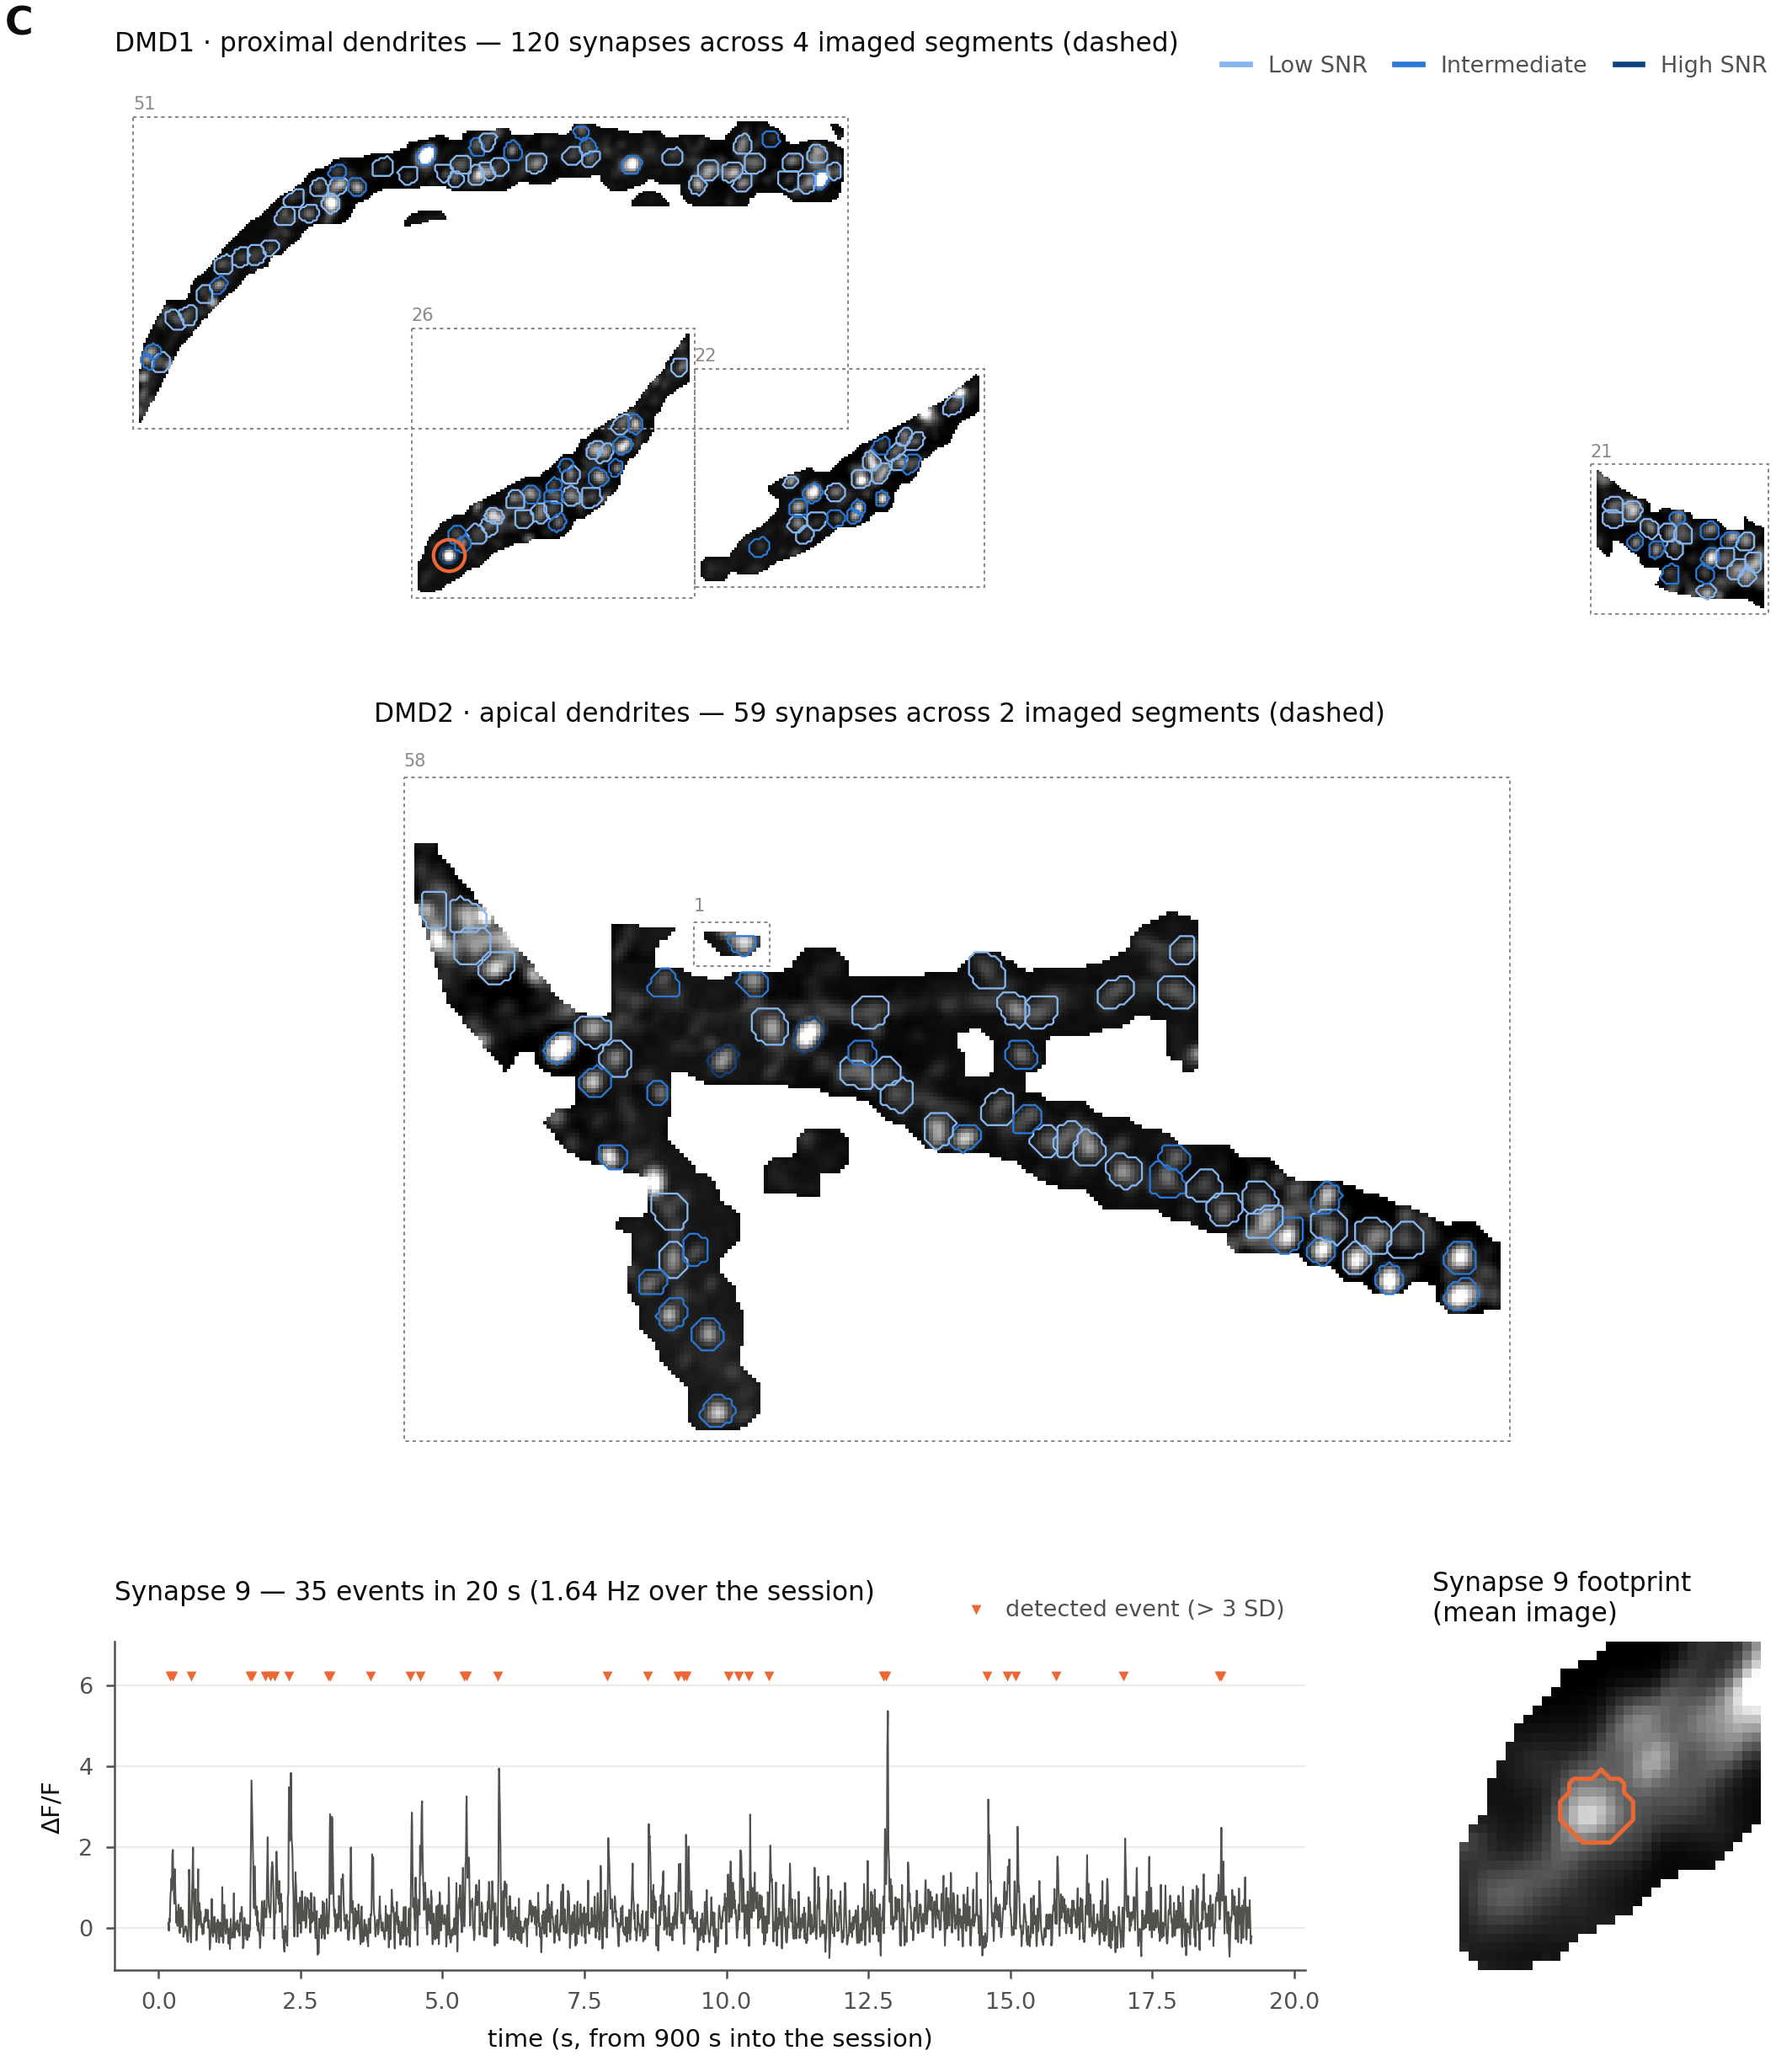

In [7]:
panels.render_panel_c(sess, m_ex, OUT_DIR)
display(Image(str(OUT_DIR / "figure7_panelC_slap2_glutamate.png")))

#### Panel G — measuring signal and noise, and the class definition

Top: the two steps of the measurement on 5 s of the same synapse — detection on the matched-filtered
trace (3 SD), amplitude on the raw trace (brackets, coloured by amplitude bin).
Bottom left: how a synapse gets its class — the amplitude histogram of one representative synapse per
class with its < 2 / 2–4 / > 4 SD fractions. Bottom right: every classified synapse of the archive in
that feature space, coloured by the archive-wide class (rings: the three examples).

panel G  → trace window from 920 s; class examples {'Low SNR': (2, 26), 'Intermediate': (2, 21), 'High SNR': (2, 1)}


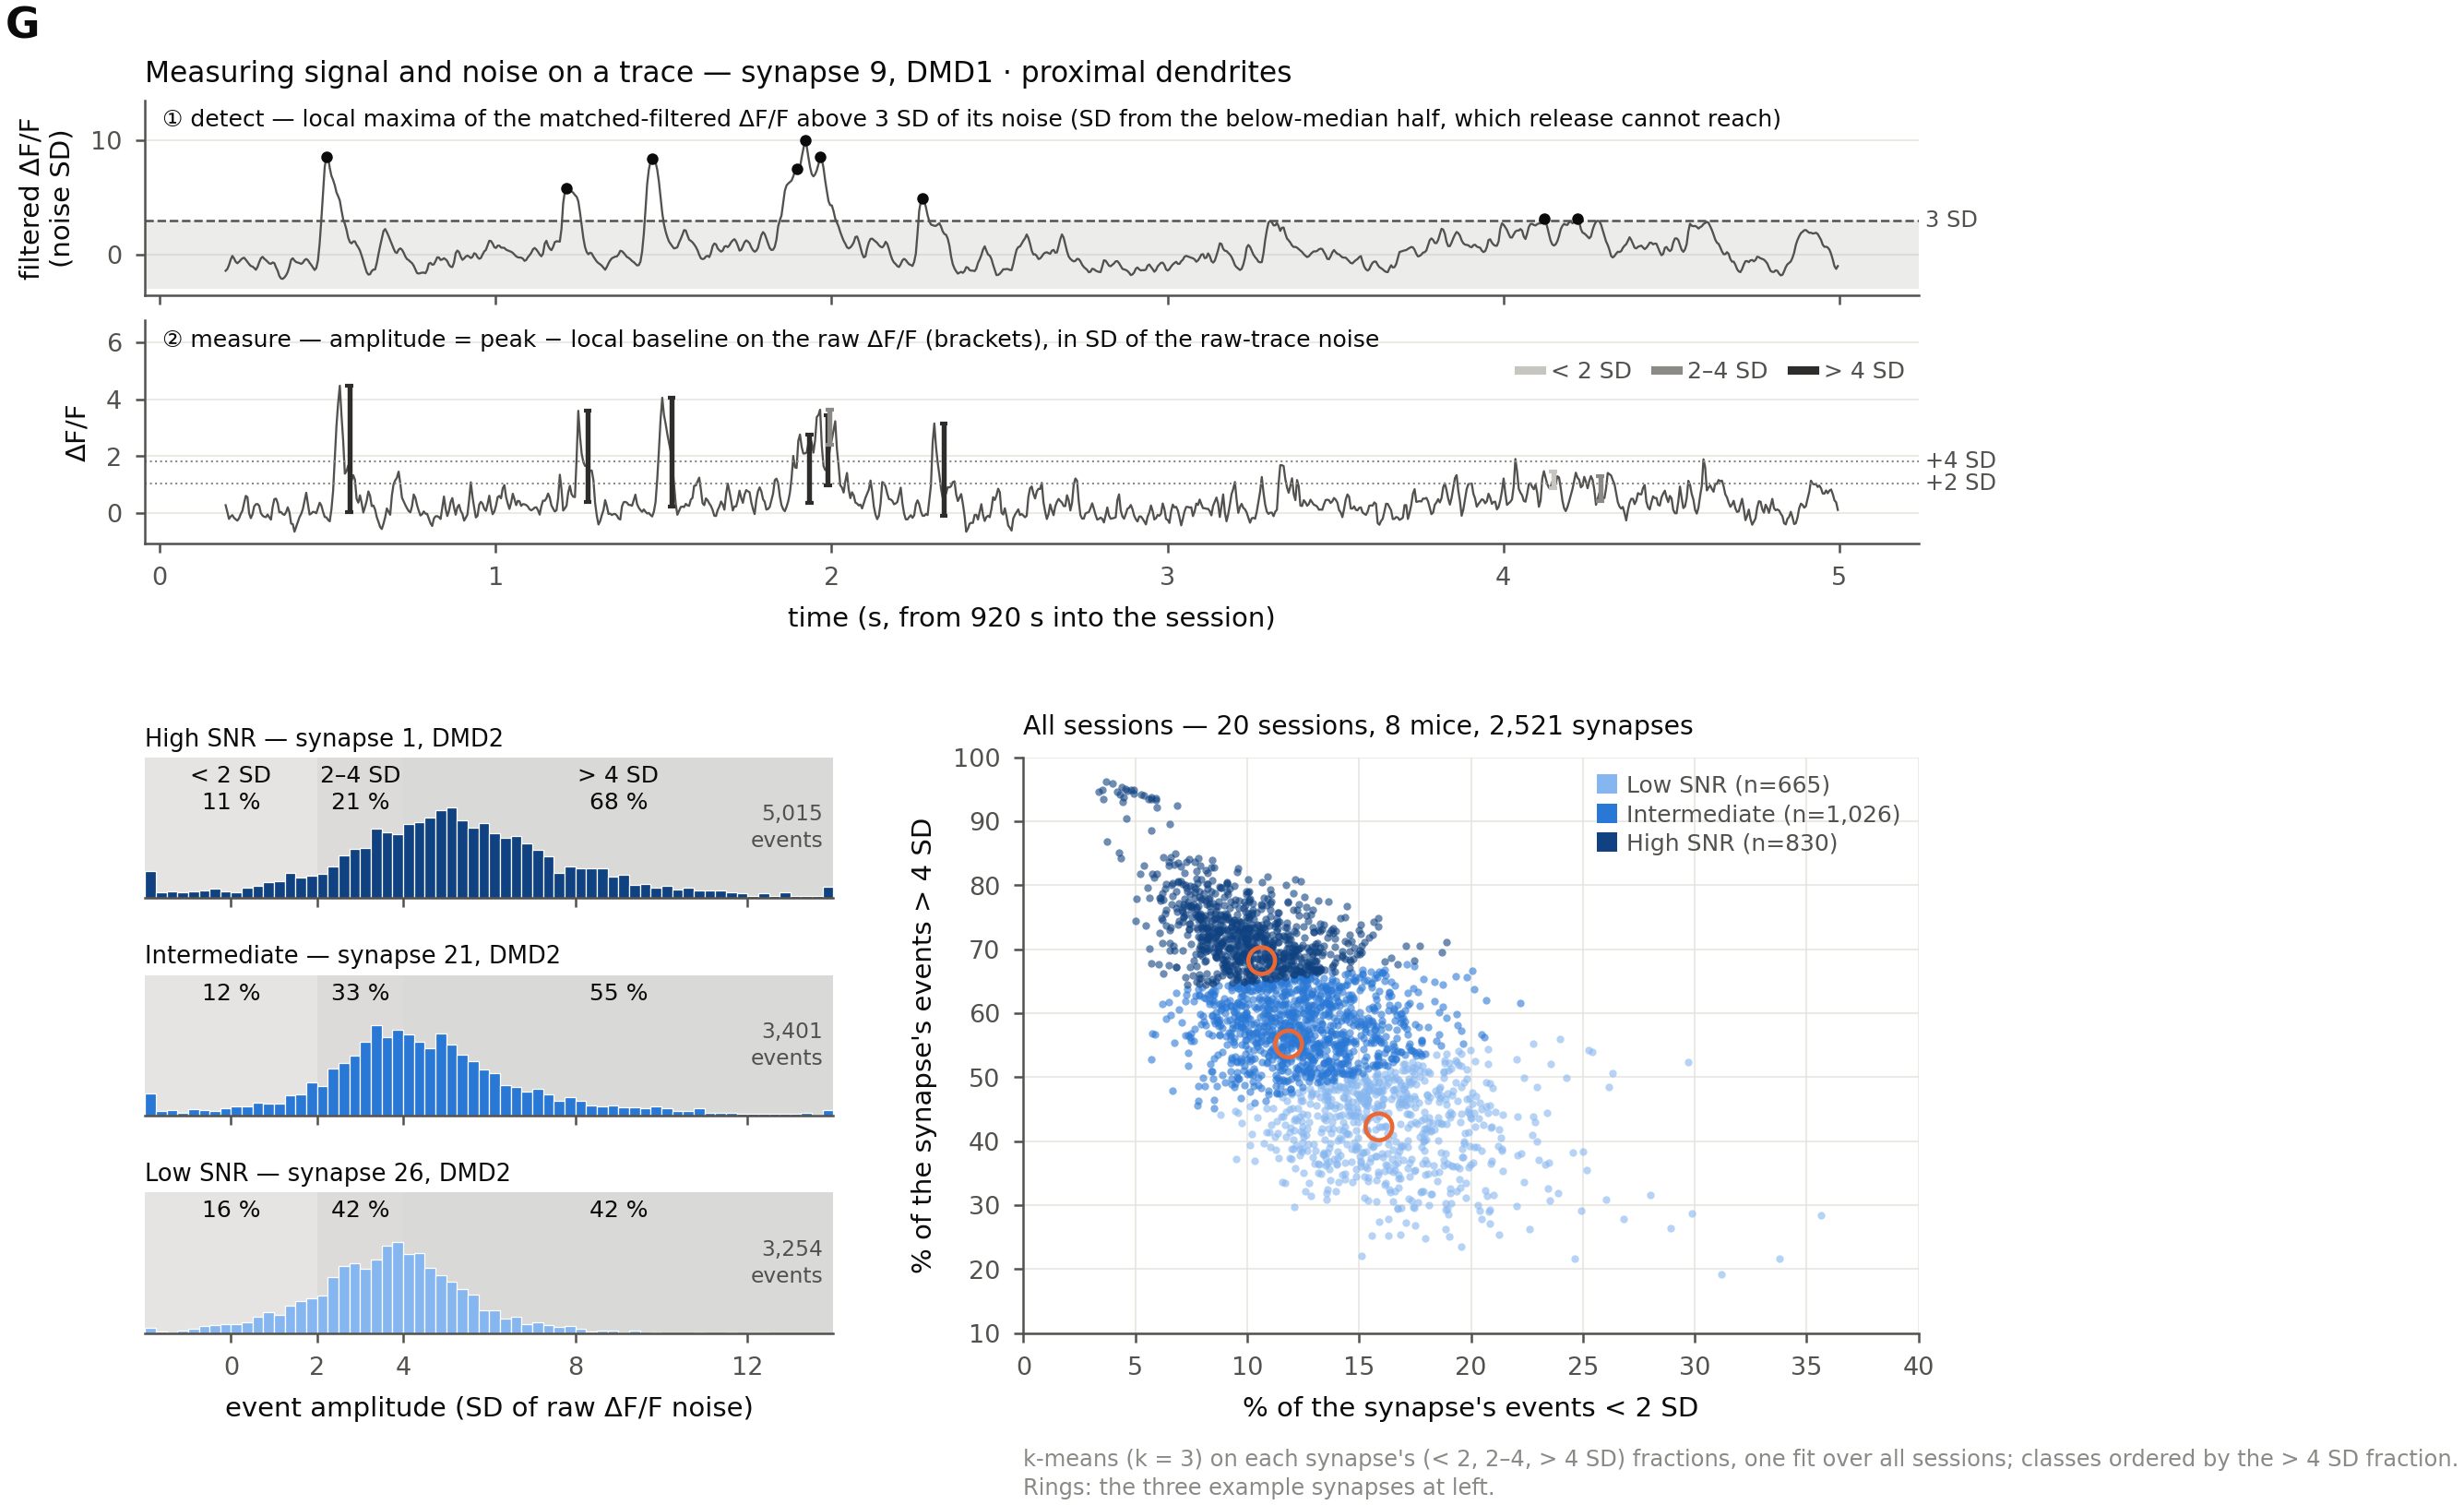

In [8]:
panels.render_panel_g(sess, m_ex, m_all, summary, OUT_DIR)
display(Image(str(OUT_DIR / "figure7_panelG_slap2_glutamate.png")))

#### Panel K — class distributions across context, compartment, and neurons

Top: event rate per synapse by stimulus context and class, one axis per cohort because their stimulus
vocabularies differ (the glutamate-only sessions ran the standard oddball paradigm, with contexts inferred
from the orientation statistics; the glutamate + calcium sessions ship one interval table per named block);
a class with fewer than 10 synapses in a cohort gets no bars.
Bottom left: class composition by dendritic compartment. Bottom right: class composition of each
neuron — one per session — in acquisition order, grouped by mouse.

panel K  → event rate (Hz/synapse) by context and class:
quality_class                     Low SNR  Intermediate  High SNR
cohort  context                                                  
glut    Blank                       0.628         0.695     0.987
        Control (random ori)        1.159         0.975     1.239
        Inter-stimulus              0.773         0.799     1.056
        Oddball deviant             1.465         1.136     1.229
        Oddball standard            0.901         0.917     1.180
        RF mapping                  0.937         0.903     1.180
glut+ca Inter-stimulus              1.502         1.176     1.319
        jitter control              1.926         1.225     1.502
        jitter oddball              0.724         1.173     1.172
        motor oddball               1.234         0.968     1.283
        movie                       0.945         1.554     1.687
        open loop prerecorded       1.798         1.167     1.487
        rf mapping 

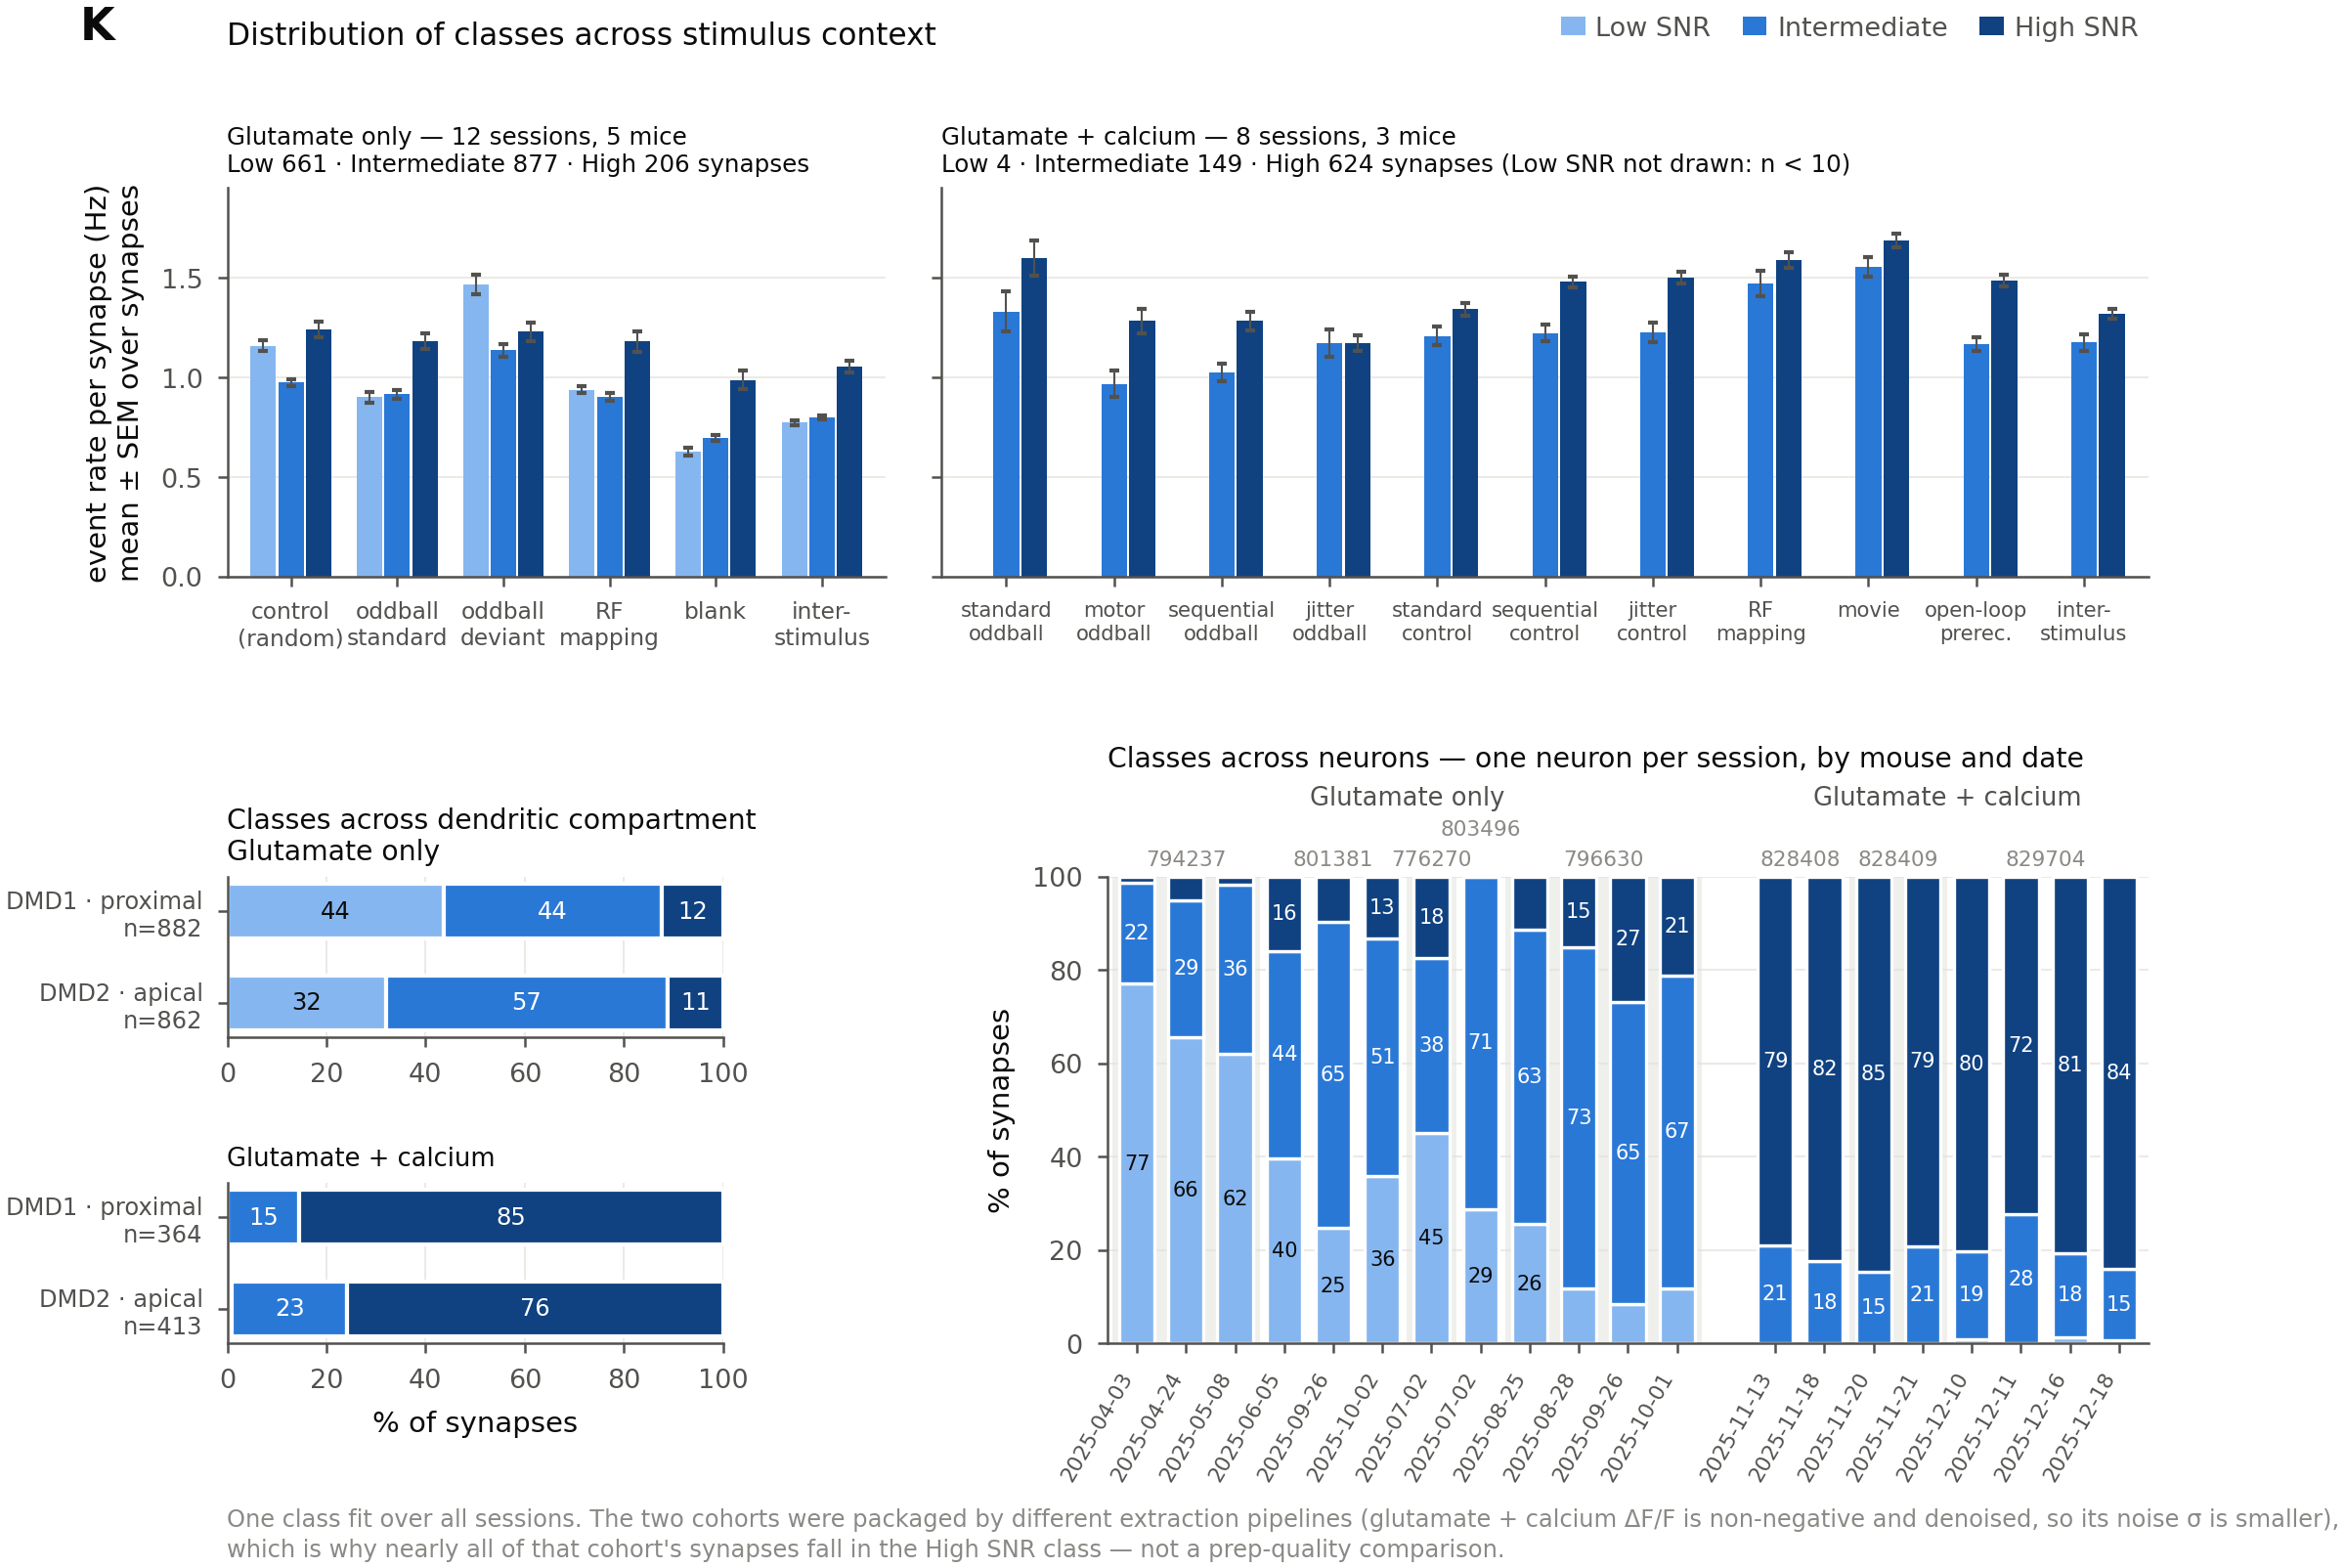

In [9]:
panels.render_panel_k(m_all, ctx_all, OUT_DIR)
display(Image(str(OUT_DIR / "figure7_panelK_slap2_glutamate.png")))

#### Variant — one continuous scale instead of the three classes

The classes are cuts through a continuum, and C and G are the two panels that can carry a colourbar
instead of a legend: an ROI map and a scatter. `color_by` renders them that way, writing
`figure7_panel{C,G}_slap2_glutamate_gradient.svg/.png` next to the defaults; the class versions above
are unchanged. Panel K keeps the classes — a stacked or grouped bar needs a categorical variable, and
the three-class scheme is what keeps this column comparable to the mesoscope column of #156.

The scalar is `median_event_raw_sd`, the synapse's median event amplitude in SD of its own noise: the
same unit as the rest of panel G, the centre of mass of the histograms in G-ii, and spearman 0.99 with
the > 4 SD fraction the classes are ordered by. `robust_snr` and `frac_events_gt4sd` are also accepted.
`robust_snr` is the obvious "SNR" but a poor gradient — its class medians (2.32 / 2.65 / 2.70
archive-wide) overlap almost completely, and every synapse above 10 is in the glutamate + calcium
cohort, whose non-negative ΔF/F shrinks σ.

Colour scales are per panel, not shared: C spans this session's synapses (2–98th percentile), G spans
the archive. So the glutamate + calcium cohort reading warmer in G is that same ΔF/F offset, not a
prep difference. ROI outlines in C get a dark halo, because they sit on bright puncta separated by
black background and a single stroke colour cannot stay legible on both.

panel C  → example synapse 9 (DMD1), 5074 events, class High SNR


panel G  → trace window from 920 s; class examples {'Low SNR': (2, 26), 'Intermediate': (2, 21), 'High SNR': (2, 1)}


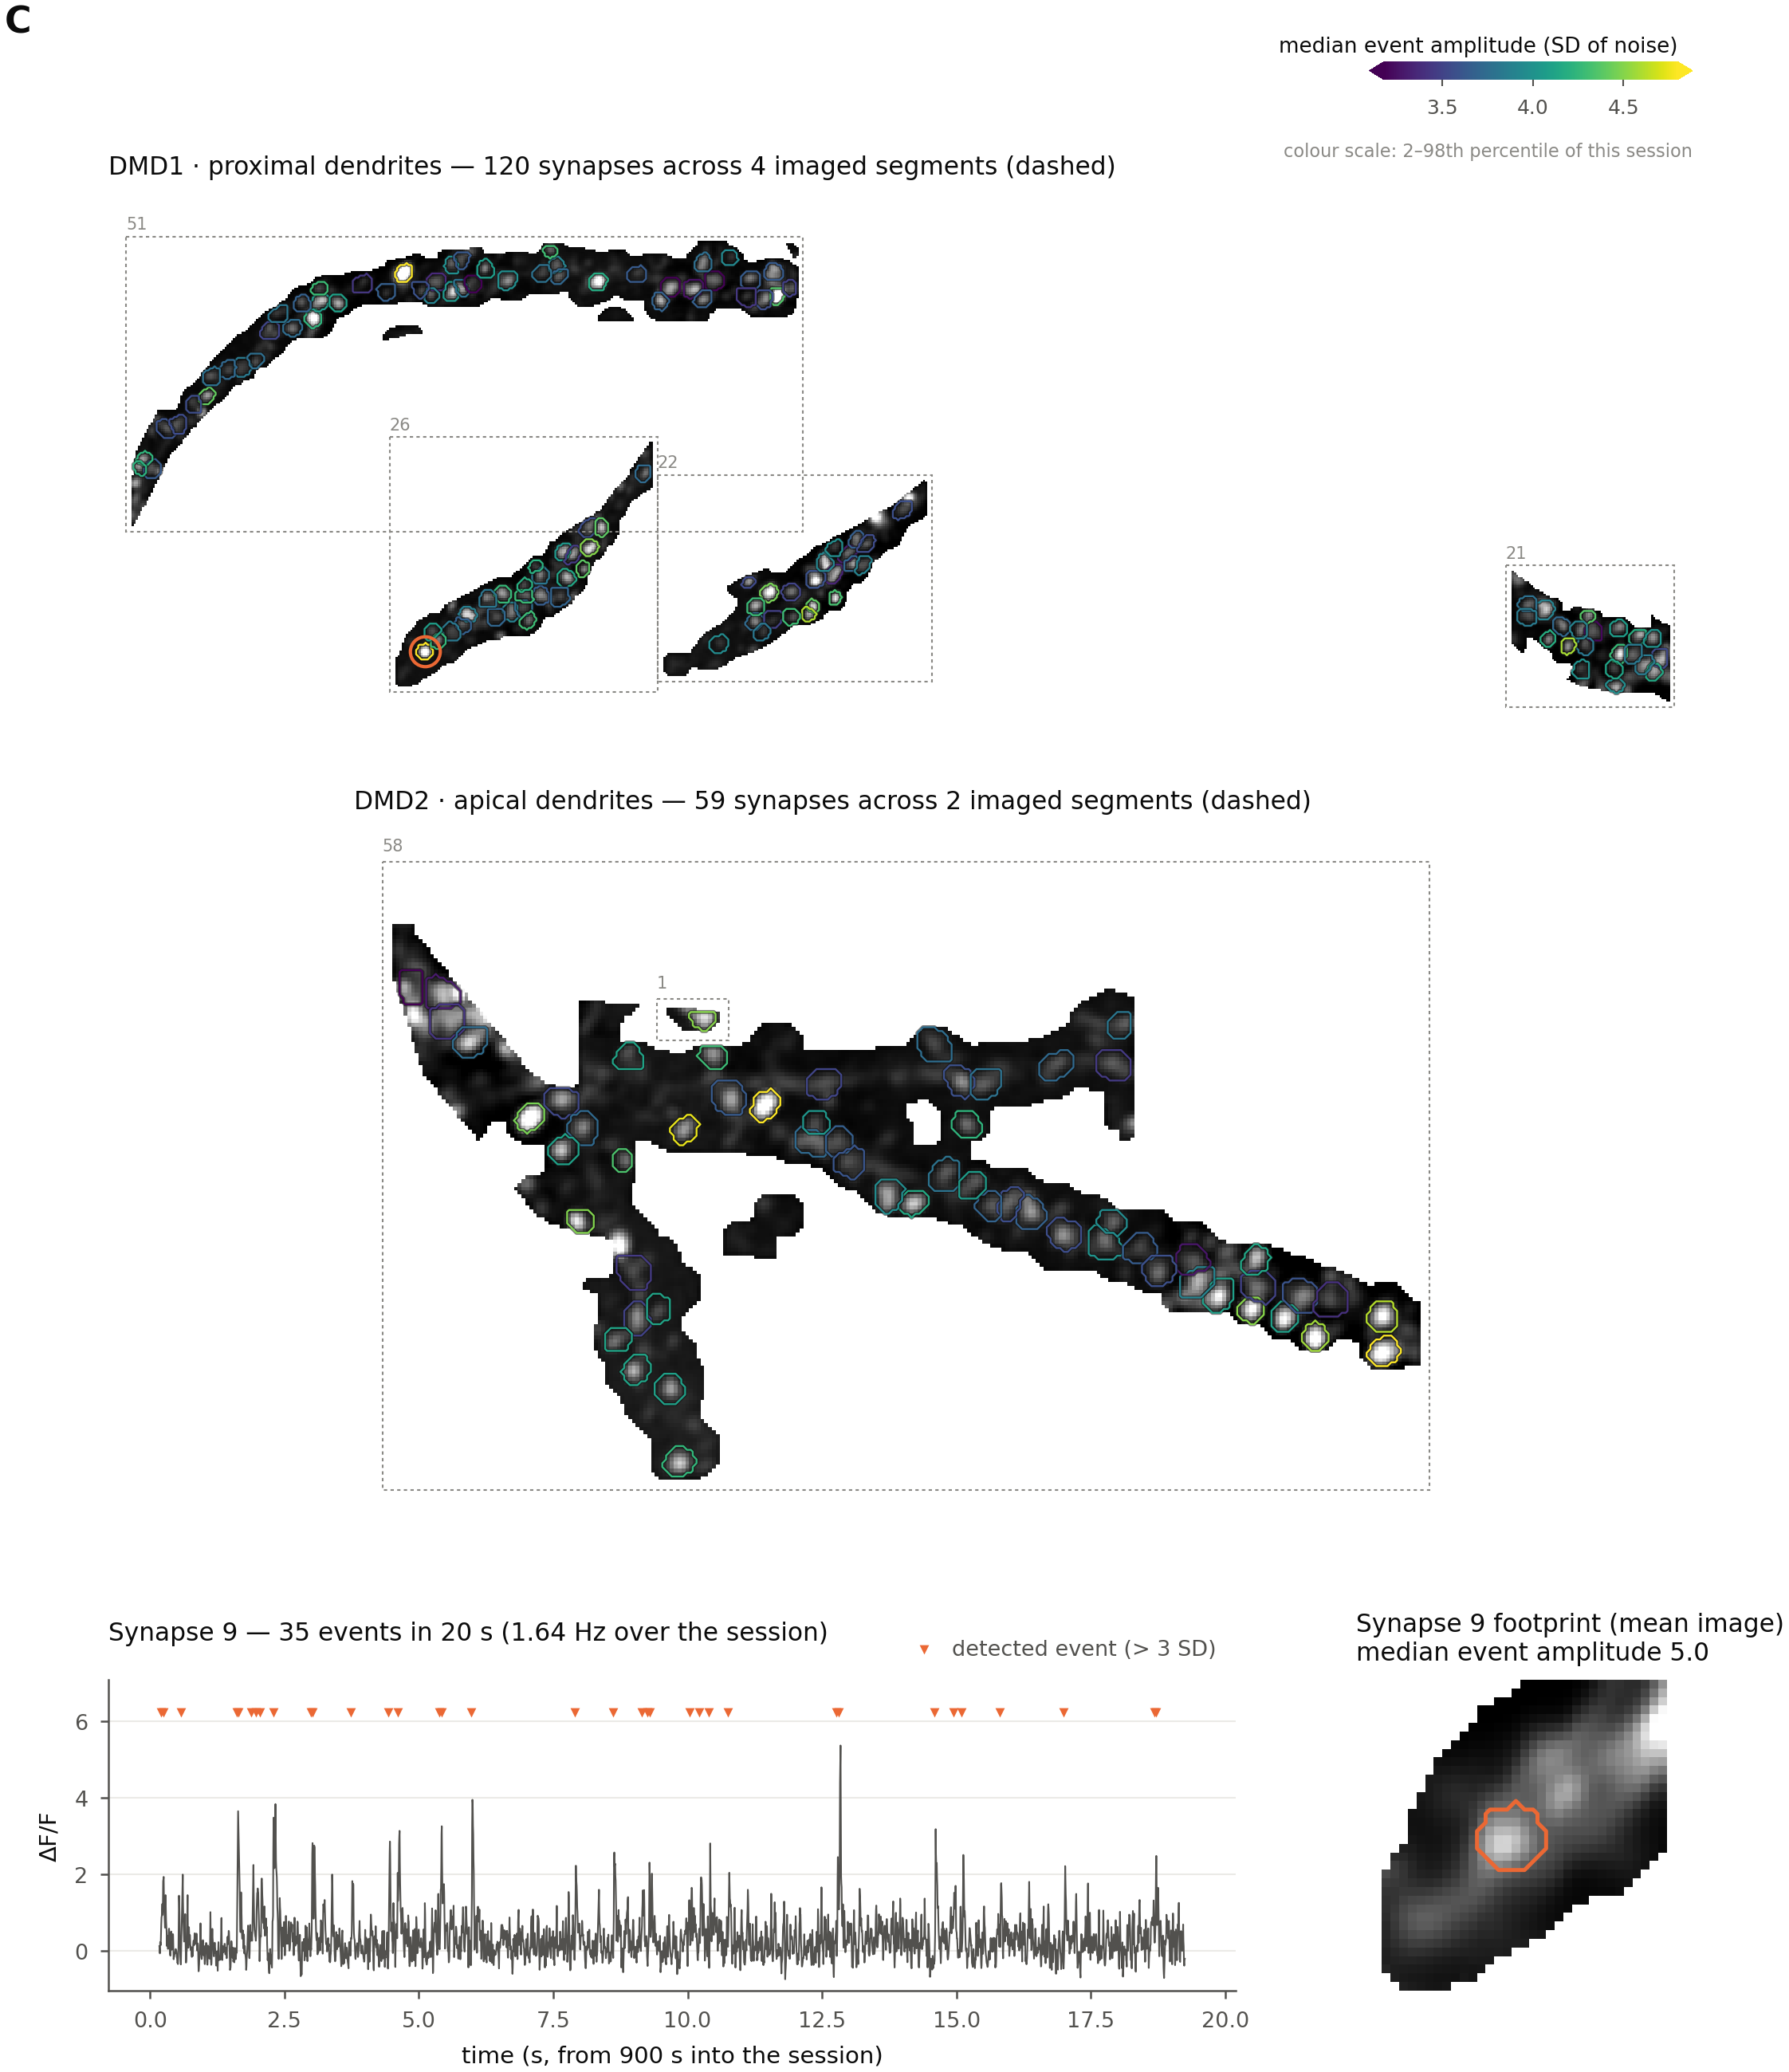

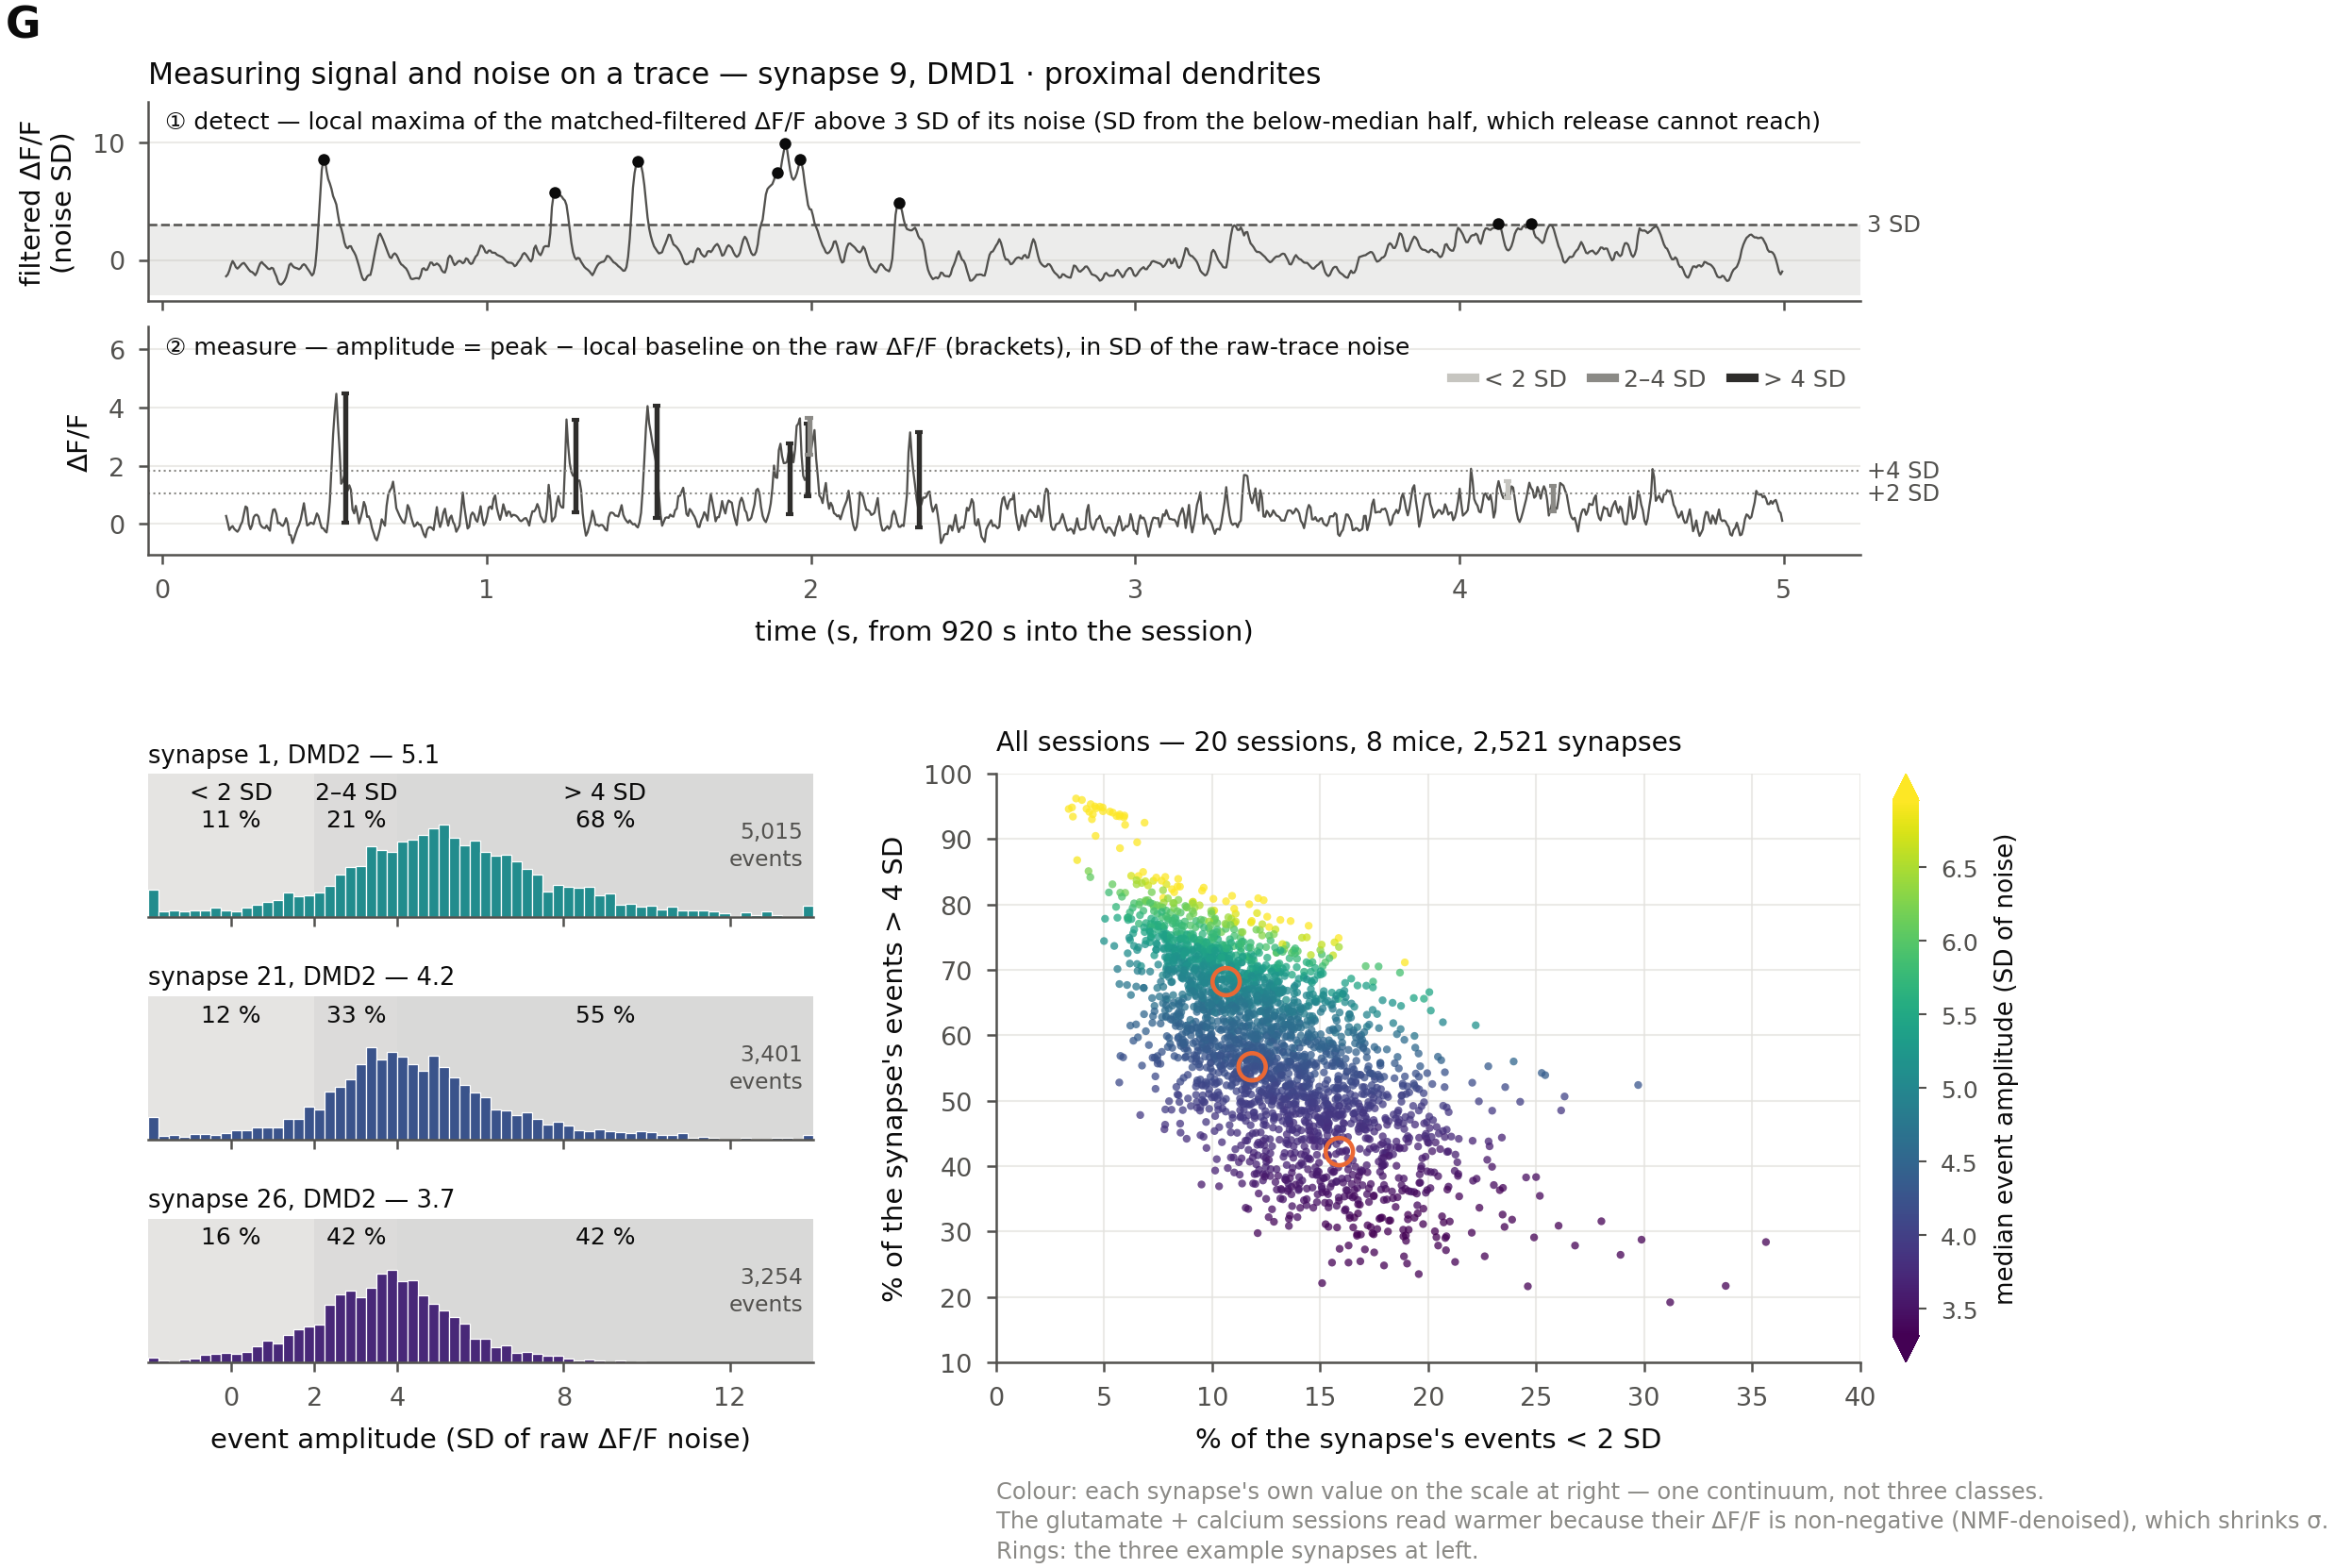

In [10]:
COLOR_BY = "median_event_raw_sd"          # or "robust_snr", "frac_events_gt4sd"

panels.render_panel_c(sess, m_ex, OUT_DIR, color_by=COLOR_BY)
panels.render_panel_g(sess, m_ex, m_all, summary, OUT_DIR, color_by=COLOR_BY)
for p in ("C", "G"):
    display(Image(str(OUT_DIR / f"figure7_panel{p}_slap2_glutamate_gradient.png")))

In [11]:
print("Wrote:")
for f in sorted(OUT_DIR.glob("figure7_panel*")):
    print(f"  {f}  ({f.stat().st_size/1024:.0f} KB)")

Wrote:
  plots_figure7_slap2_glutamate/figure7_panelC_slap2_glutamate.png  (447 KB)
  plots_figure7_slap2_glutamate/figure7_panelC_slap2_glutamate.svg  (384 KB)
  plots_figure7_slap2_glutamate/figure7_panelC_slap2_glutamate_gradient.png  (505 KB)
  plots_figure7_slap2_glutamate/figure7_panelC_slap2_glutamate_gradient.svg  (562 KB)
  plots_figure7_slap2_glutamate/figure7_panelG_slap2_glutamate.png  (543 KB)
  plots_figure7_slap2_glutamate/figure7_panelG_slap2_glutamate.svg  (330 KB)
  plots_figure7_slap2_glutamate/figure7_panelG_slap2_glutamate_gradient.png  (595 KB)
  plots_figure7_slap2_glutamate/figure7_panelG_slap2_glutamate_gradient.svg  (413 KB)
  plots_figure7_slap2_glutamate/figure7_panelK_slap2_glutamate.png  (334 KB)
  plots_figure7_slap2_glutamate/figure7_panelK_slap2_glutamate.svg  (197 KB)


## Reading the panels

**Signal quality (C, G).** The archive holds 2,540 extracted synapses over 20 sessions and 8 mice
(8.7 M detected events); 9 sources with a rectified trace (no measurable noise floor) carry no class,
leaving 2,521 classified synapses — 665 Low, 1,026 Intermediate, 830 High SNR under one fit. In the
example session, 179 synapses give ~556 k events at a median 1.04 Hz per synapse with a measured
false-positive fraction of 0.6 %. Archive-wide, the glutamate-only cohort's false-positive fraction
averages 0.3 % and is monotone in class — 0.7 % (Low), 0.1 % (Intermediate), 0.03 % (High SNR) — a
sanity check that the classes track signal quality. In the glutamate + calcium cohort the fraction is 0
by construction (non-negative traces have no downward crossings) and the 95/50 SNR is higher for the
same reason (median 3.3 vs 2.4).

**Class definition (G).** The classes separate along the > 4 SD fraction (medians 43 / 58 / 72 %) while
the < 2 SD fraction falls from Low to High (16 → 10 %). Because the two cohorts sit on different noise
scales, the single yardstick splits them: the glutamate + calcium sessions are 80 % High SNR (624 of 777,
only 4 Low), the glutamate-only sessions 12 % (206 of 1,744). Within the glutamate-only cohort event rate
barely differs between Low and Intermediate (0.80 vs 0.78 Hz median) and is higher for High SNR (1.04 Hz).

**Across context (K).** In the 12 standard-paradigm sessions the rate ordering is the same for every
class: oddball deviant (1.1–1.5 Hz) > control (1.0–1.2) > oddball standard ≈ RF mapping (0.9–1.2) >
inter-stimulus (0.8–1.1) > blank (0.6–1.0). Low-SNR synapses respond most to deviants (1.47 Hz) and
High-SNR synapses run ~0.2–0.3 Hz above the other classes in most contexts. In the 8 glutamate + calcium
sessions (Low SNR has 4 synapses and is not drawn) High-SNR synapses fire 0.1–0.4 Hz faster than
Intermediate in every block, most in the standard-oddball block (1.6 vs 1.3 Hz).

**Across compartment and neurons (K).** Proximal (DMD1) and apical (DMD2) dendrites have the same
High-SNR share in the glutamate-only cohort (12 vs 11 %), and apical dendrites carry fewer Low-SNR
synapses (32 vs 44 %); in the glutamate + calcium cohort the proximal plane is the richer one (85 vs
76 % High SNR). Within a cohort, composition varies more between neurons than between compartments and is
consistent within a mouse (glutamate-only High-SNR share: sub-796630 11–27 %, sub-801381 10–16 %,
sub-794237 1–5 %); across cohorts the per-neuron bars mostly show the pipeline difference.

Caveats worth repeating with these numbers: the glutamate-only stimulus contexts are inferred from the
orientation statistics of a single presentation table (the glutamate + calcium sessions ship named
block tables); and the two cohorts were packaged by different extraction pipelines (glutamate + calcium
ΔF/F is non-negative and denoised, so its noise σ is smaller), which is why one archive-wide fit puts
nearly all of that cohort in the High SNR class — not a prep-quality comparison.
